# 01: Business and Data Understanding

**SDC Master's Final Project: soccernet-setpiece-vision**  
Moritz Philipp Haaf · MSc AI Applied to Sports · Sports Data Campus

CRISP-DM phases 1 (Business Understanding) and 2 (Data Understanding).  
Scope: StatsBomb Open Data only. No video processing in this notebook.

## 0. Setup and Imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsbombpy import sb
from statsbombpy.api_client import NoAuthWarning
from mplsoccer import Pitch, VerticalPitch

warnings.filterwarnings("ignore", category=NoAuthWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COMPETITION_ID = 55  # UEFA Euro 2024
SEASON_ID = 282
PITCH_LENGTH_M = 105
PITCH_WIDTH_M = 68
STATSBOMB_X_MAX = 120
STATSBOMB_Y_MAX = 80

sns.set_theme(style="whitegrid", context="notebook")
print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs dir : {OUTPUTS_DIR}")

Project root: /Users/mph/Dev/itzmore-mph/MAIS-projects/final-master-project/soccernet-setpiece-vision
Outputs dir : /Users/mph/Dev/itzmore-mph/MAIS-projects/final-master-project/soccernet-setpiece-vision/outputs


## 1. Business Understanding

**Problem.** Top-tier optical tracking systems (Opta, StatsBomb, SkillCorner) are budget-intensive and effectively exclude second divisions, women's football, youth academies and most scouting contexts. The data gap reinforces a competitive gap.

**Solution.** Derive Pitch Control from broadcast video using a reproducible open-source CV pipeline (YOLOv8 detection + homography + KMeans team assignment + Laurie Shaw pitch control). Ground truth is supplied by event data.

**Why set pieces.** Set pieces account for roughly 30 % of tournament goals, the broadcast camera is near-static during execution, all relevant players are typically in frame, and the ball position is fixed and known from the event feed. This makes them the highest-signal, lowest-noise entry point for a CV pipeline.

**Stakeholders.** 2. Bundesliga, Championship, Frauen-Bundesliga, NWSL, academies and scouting departments, i.e. competitions where commercial tracking is unavailable but broadcast video is.

## 2. Data Sources Overview

| Source | Usage | Why |
|---|---|---|
| **SoccerNet GSR** (`/Volumes/MPH-ExternalStorage/soccernet-gsr`) | Video clips + CV annotations | Train/evaluate the CV pipeline (notebooks 02–03) |
| **StatsBomb 360 Euro 2024** (`competition_id=55`, `season_id=282`) | Freeze-frame coordinates of all visible players | Analytical validation ground truth (51 matches) |
| **Pipeline output** (`outputs/*.parquet`) | Pitch Control surfaces from broadcast frames | Distributional comparison vs StatsBomb 360 |

**Validation strategy.** Distributional, not frame-matched. SoccerNet GSR clips and StatsBomb Euro 2024 matches are different datasets, there is no per-frame correspondence. We compare distributions of Pitch Control values across comparable set-piece types.

## 3. StatsBomb Euro 2024 Data Loading

### 3.1 Competitions

In [2]:
competitions = sb.competitions()
euro_2024 = competitions[(competitions["competition_id"] == COMPETITION_ID) & (competitions["season_id"] == SEASON_ID)]
euro_2024

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
68,55,282,Europe,UEFA Euro,male,False,True,2024,2024-09-28T16:51:20.698794,2025-03-24T14:12:30.785094,2025-03-24T14:12:30.785094,2024-09-28T16:51:20.698794


### 3.2 Matches

In [3]:
matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
print(f"Matches shape: {matches.shape}")
matches.head()

Matches shape: (51, 55)


,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,3942819,2024-07-10,22:00:00.000,1,2,available,available,2024-07-15T07:54:23.583297,2024-07-15T07:57:36.684453,6,...,Netherlands,277,Gareth Southgate,None,1970-09-03,68,England,1.1.0,2,2
1,3943043,2024-07-14,22:00:00.000,2,1,available,available,2024-07-15T15:48:50.315500,2024-07-15T15:52:24.778809,7,...,Spain,277,Gareth Southgate,None,1970-09-03,68,England,1.1.0,2,2
2,3942752,2024-07-09,22:00:00.000,2,1,available,available,2024-07-10T08:51:07.032303,2024-07-10T13:01:26.597509,6,...,Spain,545,Didier Deschamps,None,1968-10-15,78,France,1.1.0,2,2
3,3942382,2024-07-06,22:00:00.000,2,1,available,available,2024-07-10T06:50:04.068615,2024-07-10T06:56:35.146850,5,...,Netherlands,232,Vincenzo Montella,None,1974-06-18,112,Italy,1.1.0,2,2
4,3942349,2024-07-05,22:00:00.000,0,0,available,available,2024-07-12T01:57:15.210934,2024-07-12T02:00:16.871522,5,...,Spain,545,Didier Deschamps,None,1968-10-15,78,France,1.1.0,2,2


### 3.3 Summary

In [4]:
teams = sorted(set(matches["home_team"]).union(matches["away_team"]))
match_dates = pd.to_datetime(matches["match_date"])
print(f"Number of matches : {len(matches)}")
print(f"Date range        : {match_dates.min().date()} -> {match_dates.max().date()}")
print(f"Total teams       : {len(teams)}")
print(f"Teams             : {', '.join(teams)}")

Number of matches : 51
Date range        : 2024-06-14 -> 2024-07-14
Total teams       : 24
Teams             : Albania, Austria, Belgium, Croatia, Czech Republic, Denmark, England, France, Georgia, Germany, Hungary, Italy, Netherlands, Poland, Portugal, Romania, Scotland, Serbia, Slovakia, Slovenia, Spain, Switzerland, Turkey, Ukraine


## 4. Set-Piece Extraction

Coordinate conversion from StatsBomb (120 yards × 80 yards) to metric pitch (105 m × 68 m).

In [5]:
def statsbomb_to_metres(x, y):
    """Convert StatsBomb 120x80 yards to 105x68 metres."""
    return x * (PITCH_LENGTH_M / STATSBOMB_X_MAX), y * (PITCH_WIDTH_M / STATSBOMB_Y_MAX)


def convert_freeze_frame(frame_rows: pd.DataFrame) -> list[dict]:
    """Build a list of player dicts in metric coordinates from 360 freeze-frame rows."""
    players = []
    for _, r in frame_rows.iterrows():
        loc = r.get("location")
        if loc is None or (isinstance(loc, float) and np.isnan(loc)):
            continue
        x_m, y_m = statsbomb_to_metres(loc[0], loc[1])
        players.append({
            "player_x_m": float(x_m),
            "player_y_m": float(y_m),
            "teammate": bool(r.get("teammate", False)),
            "actor": bool(r.get("actor", False)),
            "keeper": bool(r.get("keeper", False)),
        })
    return players

### 4.1 – 4.5 Loop over matches

For each match: load events, filter corners and direct free kicks, load 360 freeze frames, join on `event_uuid`, convert to metres, accumulate.

In [6]:
# Set-piece extraction loop. Robust: explicit per-match diagnostics on
# events/frames failures, retry with backoff for transient statsbombpy errors,
# and a summary of frame-attach success at the end.

import time

rows = []
skipped = []
diag_frames_empty = []
match_ids = matches["match_id"].tolist()


def _fetch_with_retry(fn, *, attempts: int = 3, delay: float = 1.0, **kwargs):
    """Call statsbombpy fn(**kwargs) up to N times with linear backoff."""
    last = None
    for k in range(attempts):
        try:
            return fn(**kwargs)
        except Exception as e:
            last = e
            time.sleep(delay * (k + 1))
    raise last


for i, mid in enumerate(match_ids, 1):
    mid = int(mid)
    try:
        events = _fetch_with_retry(sb.events, match_id=mid)
    except Exception as e:
        skipped.append((mid, f"events: {type(e).__name__}: {e}"))
        continue

    if events is None or events.empty:
        skipped.append((mid, "events empty"))
        continue

    corners = events[(events["type"] == "Pass") & (events.get("pass_type") == "Corner")].copy()
    corners["event_type"] = "corner"

    pass_type_col = events["pass_type"] if "pass_type" in events.columns else pd.Series([None] * len(events), index=events.index)
    shot_type_col = events["shot_type"] if "shot_type" in events.columns else pd.Series([None] * len(events), index=events.index)
    start_x = events["location"].apply(lambda l: l[0] if isinstance(l, list) and len(l) >= 1 else np.nan)
    fk_shot = (events["type"] == "Shot") & (shot_type_col == "Free Kick")
    fk_pass_attacking = (events["type"] == "Pass") & (pass_type_col == "Free Kick") & (start_x >= 80)
    free_kicks = events[fk_shot | fk_pass_attacking].copy()
    free_kicks["event_type"] = "free_kick"

    set_pieces = pd.concat([corners, free_kicks], ignore_index=True)
    if set_pieces.empty:
        continue

    # Frames: retry, log empty/None reason explicitly
    try:
        frames = _fetch_with_retry(sb.frames, match_id=mid)
    except Exception as e:
        diag_frames_empty.append((mid, f"frames raised: {type(e).__name__}: {e}"))
        frames = None

    if frames is None:
        frames_by_event = {}
    elif frames.empty:
        diag_frames_empty.append((mid, "frames returned empty df"))
        frames_by_event = {}
    else:
        ff_key = "event_uuid" if "event_uuid" in frames.columns else "id"
        frames_by_event = {eid: grp for eid, grp in frames.groupby(ff_key)}

    for _, ev in set_pieces.iterrows():
        loc = ev.get("location")
        if loc is None or (isinstance(loc, float) and np.isnan(loc)):
            continue
        ball_x_m, ball_y_m = statsbomb_to_metres(loc[0], loc[1])
        ev_id = ev.get("id")
        ff_rows = frames_by_event.get(ev_id)
        ff = convert_freeze_frame(ff_rows) if ff_rows is not None else []
        rows.append({
            "match_id": int(mid),
            "event_id": ev_id,
            "event_type": ev["event_type"],
            "period": int(ev.get("period", 0) or 0),
            "minute": int(ev.get("minute", 0) or 0),
            "second": int(ev.get("second", 0) or 0),
            "team": ev.get("team"),
            "ball_x_m": float(ball_x_m),
            "ball_y_m": float(ball_y_m),
            "freeze_frame": ff,
        })

    if i % 10 == 0:
        n_with_ff_so_far = sum(1 for r in rows if r["freeze_frame"])
        print(f"  processed {i}/{len(match_ids)} matches  |  set pieces: {len(rows)}  |  with FF: {n_with_ff_so_far}")

n_with_ff_total = sum(1 for r in rows if r["freeze_frame"])
print(f"\nDone. Total set pieces: {len(rows)}  |  With FF: {n_with_ff_total}  |  Coverage: {100*n_with_ff_total/max(len(rows),1):.1f} %")
print(f"Matches with frames issue: {len(diag_frames_empty)}  |  Matches fully skipped: {len(skipped)}")
for mid, why in diag_frames_empty[:5]:
    print(f"  frames-issue {mid}: {why}")
for mid, why in skipped[:5]:
    print(f"  skipped      {mid}: {why}")


  processed 10/51 matches  |  set pieces: 119  |  with FF: 71


  processed 20/51 matches  |  set pieces: 276  |  with FF: 173


  processed 30/51 matches  |  set pieces: 415  |  with FF: 261


  processed 40/51 matches  |  set pieces: 560  |  with FF: 358


  processed 50/51 matches  |  set pieces: 697  |  with FF: 448



Done. Total set pieces: 706  |  With FF: 453  |  Coverage: 64.2 %
Matches with frames issue: 0  |  Matches fully skipped: 0


### 4.6 Build the cleaned DataFrame

In [7]:
setpieces = pd.DataFrame(rows)
print(f"Set-pieces frame shape: {setpieces.shape}")
setpieces.head()

Set-pieces frame shape: (706, 10)


,match_id,event_id,event_type,period,minute,second,team,ball_x_m,ball_y_m,freeze_frame
0,3942819,87a672a3-b150-4a14-8367-40507453377d,corner,1,29,7,Netherlands,105.0,68.000,"[{'player_x_m': 80.55142912831214, 'player_y_m..."
1,3942819,793b5405-829c-46ce-9cd8-1ae147d22293,corner,2,64,52,Netherlands,105.0,68.000,[]
2,3942819,ba12cd56-3e94-42ae-bffd-f613aaffb397,corner,2,68,25,Netherlands,105.0,68.000,[]
3,3942819,2e915dce-685b-45b6-b69a-6884e33afbf7,free_kick,1,10,31,England,79.1,15.045,"[{'player_x_m': 75.94551348768061, 'player_y_m..."
4,3942819,fc0a548e-0b43-4921-8fae-a18075acee44,free_kick,1,11,32,England,73.5,45.050,"[{'player_x_m': 73.5, 'player_y_m': 45.05, 'te..."


## 5. Exploratory Data Analysis

### 5.1 Set-piece counts

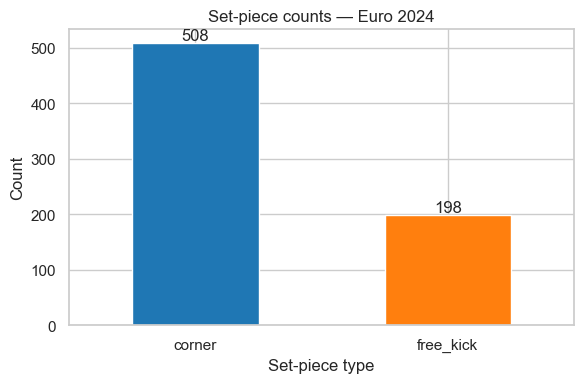

event_type
corner       508
free_kick    198
Name: count, dtype: int64


In [8]:
counts = setpieces["event_type"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e"])
ax.set_title("Set-piece counts, Euro 2024")
ax.set_xlabel("Set-piece type")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_setpiece_counts.png", dpi=150)
plt.show()
print(counts)

### 5.2 Set-piece locations on a metric pitch

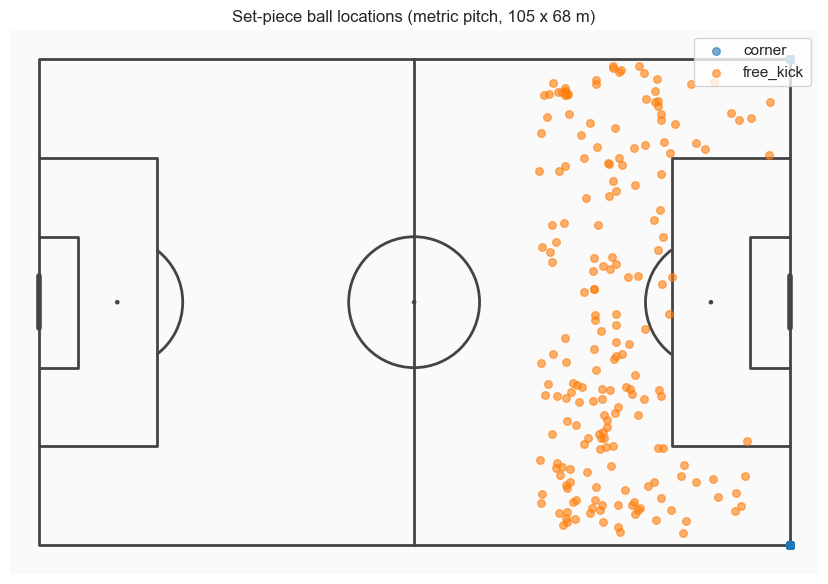

In [9]:
pitch = Pitch(pitch_type="custom", pitch_length=PITCH_LENGTH_M, pitch_width=PITCH_WIDTH_M,
              line_color="#444", pitch_color="#fafafa")
fig, ax = pitch.draw(figsize=(10, 6))
for et, color in [("corner", "#1f77b4"), ("free_kick", "#ff7f0e")]:
    sub = setpieces[setpieces["event_type"] == et]
    pitch.scatter(sub["ball_x_m"], sub["ball_y_m"], ax=ax, s=30, alpha=0.6, color=color, label=et)
ax.legend(loc="upper right")
ax.set_title("Set-piece ball locations (metric pitch, 105 x 68 m)")
fig.savefig(FIGURES_DIR / "02_setpiece_locations.png", dpi=150)
plt.show()

### 5.3 Players visible per freeze frame

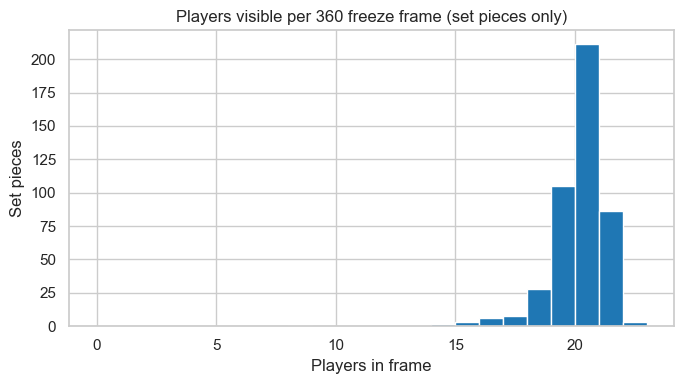

count    706.000000
mean      12.611898
std        9.485910
min        0.000000
25%        0.000000
50%       19.000000
75%       20.000000
max       22.000000
Name: freeze_frame, dtype: float64


In [10]:
ff_counts = setpieces["freeze_frame"].apply(len)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ff_counts[ff_counts > 0], bins=range(0, ff_counts.max() + 2), color="#1f77b4", edgecolor="white")
ax.set_title("Players visible per 360 freeze frame (set pieces only)")
ax.set_xlabel("Players in frame")
ax.set_ylabel("Set pieces")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_players_per_frame.png", dpi=150)
plt.show()
print(ff_counts.describe())

### 5.4 Freeze-frame coverage

In [11]:
with_ff = (ff_counts > 0).sum()
without_ff = (ff_counts == 0).sum()
total = len(setpieces)
coverage_pct = 100 * with_ff / total if total else 0
print(f"With freeze frames    : {with_ff}")
print(f"Without freeze frames : {without_ff}")
print(f"Total set pieces      : {total}")
print(f"Coverage              : {coverage_pct:.1f} %")

With freeze frames    : 453
Without freeze frames : 253
Total set pieces      : 706
Coverage              : 64.2 %


### 5.5 Outcomes within 10 seconds after set-piece execution

Re-load events per match (cached by statsbombpy) and bucket the next-10-seconds outcome of each set piece.

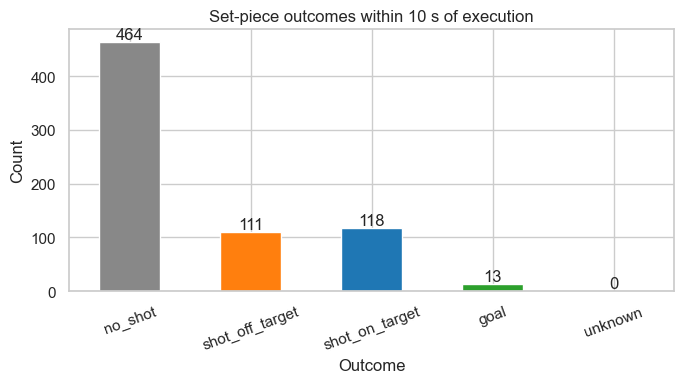

outcome_10s
no_shot            464
shot_off_target    111
shot_on_target     118
goal                13
unknown              0
Name: count, dtype: int64


In [12]:
WINDOW_SEC = 10

def bucket_outcome(events_df: pd.DataFrame, sp_row) -> str:
    t0 = sp_row["period"], sp_row["minute"] * 60 + sp_row["second"]
    sub = events_df[events_df["period"] == t0[0]].copy()
    sub["_t"] = sub["minute"] * 60 + sub["second"]
    window = sub[(sub["_t"] >= t0[1]) & (sub["_t"] <= t0[1] + WINDOW_SEC)]
    shots = window[window["type"] == "Shot"]
    if shots.empty:
        return "no_shot"
    outcomes = shots.get("shot_outcome", pd.Series(dtype=object)).dropna().tolist()
    if any(o == "Goal" for o in outcomes):
        return "goal"
    if any(o in ("Saved", "Saved To Post", "Blocked") for o in outcomes):
        return "shot_on_target"
    return "shot_off_target"


outcome_buckets = []
for mid, grp in setpieces.groupby("match_id"):
    try:
        events = sb.events(match_id=int(mid))
    except Exception:
        outcome_buckets.extend(["unknown"] * len(grp))
        continue
    for _, sp in grp.iterrows():
        outcome_buckets.append(bucket_outcome(events, sp))

setpieces["outcome_10s"] = outcome_buckets
outcome_counts = setpieces["outcome_10s"].value_counts().reindex(
    ["no_shot", "shot_off_target", "shot_on_target", "goal", "unknown"], fill_value=0
)

fig, ax = plt.subplots(figsize=(7, 4))
outcome_counts.plot(kind="bar", ax=ax, color=["#888", "#ff7f0e", "#1f77b4", "#2ca02c", "#bbb"])
ax.set_title(f"Set-piece outcomes within {WINDOW_SEC} s of execution")
ax.set_xlabel("Outcome")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
for i, v in enumerate(outcome_counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_setpiece_outcomes_10s.png", dpi=150)
plt.show()
print(outcome_counts)

## 6. Save Output

In [13]:
out_path = OUTPUTS_DIR / "setpieces.parquet"
setpieces.to_parquet(out_path, engine="pyarrow", index=False)
size_mb = out_path.stat().st_size / (1024 * 1024)

n_corner = int((setpieces["event_type"] == "corner").sum())
n_fk = int((setpieces["event_type"] == "free_kick").sum())
n_with_ff = int((setpieces["freeze_frame"].apply(len) > 0).sum())
cov = 100 * n_with_ff / len(setpieces) if len(setpieces) else 0

print(f"Total set pieces extracted   : {len(setpieces)}")
print(f"  Corners                    : {n_corner}")
print(f"  Direct free kicks          : {n_fk}")
print(f"Set pieces with freeze frame : {n_with_ff}")
print(f"Coverage                     : {cov:.1f} %")
print(f"File saved                   : {out_path}  ({size_mb:.2f} MB)")

Total set pieces extracted   : 706
  Corners                    : 508
  Direct free kicks          : 198
Set pieces with freeze frame : 453
Coverage                     : 64.2 %
File saved                   : /Users/mph/Dev/itzmore-mph/MAIS-projects/final-master-project/soccernet-setpiece-vision/outputs/setpieces.parquet  (0.21 MB)
